# Singapore Public Transport Ridership — Exploratory Data Analysis

This notebook explores the Singapore public transport ridership data (MRT, LRT, and Bus) from LTA DataMall.

# Objectives
- Understand the structure and shape of the data
- Identify trends, seasonality, and anomalies (especially COVID-19 impact)
- Prepare data for time-series modelling with ARIMA and Prophet

In [1]:
# ================================
# 1. Imports
# ================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inline in the notebook
%matplotlib inline

# Set default plot style
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)

In [2]:
# ================================
# 2. Load Data
# ================================
import sys
sys.path.append("src")

from load_data import load_ridership_data

# This loads the ridership data
df = load_ridership_data()

# This preview the data
df.head(10)

,month,mode,ridership
0,Jan-19,MRT,3462000
1,Jan-19,LRT,218000
2,Jan-19,Public Bus,4250000
3,Feb-19,MRT,3248000
4,Feb-19,LRT,206000
5,Feb-19,Public Bus,4010000
6,Mar-19,MRT,3383000
7,Mar-19,LRT,209000
8,Mar-19,Public Bus,4111000
9,Apr-19,MRT,3400000


## 3. Data Overview

Understanding the structure, shape, and basic statistics of the dataset.

In [3]:
# ================================
# 3. Data Overview
# ================================

# Shape of the dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:", df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Unique transport modes
print("\nTransport Modes:")
print(df['mode'].value_counts())

# Date range
print("\nDate Range:")
print(f"From: {df['month'].min()} to {df['month'].max()}")

# Summary statistics
print("\nRidership Summary Statistics:")
print(df.groupby('mode')['ridership'].describe())

Shape: (216, 3)

Columns: ['month', 'mode', 'ridership']

Data Types:
month          str
mode           str
ridership    int64
dtype: object

Missing Values:
month        0
mode         0
ridership    0
dtype: int64

Transport Modes:
mode
MRT           72
LRT           72
Public Bus    72
Name: count, dtype: int64

Date Range:
From: Apr-19 to Sep-24

Ridership Summary Statistics:
            count          mean            std        min        25%  \
mode                                                                   
LRT          72.0  1.821528e+05   35195.894336    47000.0   166750.0   
MRT          72.0  2.817431e+06  686279.042873   602000.0  2363750.0   
Public Bus   72.0  3.504931e+06  592192.567805  1187000.0  3201000.0   

                  50%        75%        max  
mode                                         
LRT          193500.0   208250.0   220000.0  
MRT         3089500.0  3360750.0  3604000.0  
Public Bus  3633500.0  3880250.0  4300000.0  


## 4. Time Series Visualization

Plotting ridership trends over time to identify patterns, seasonality, and anomalies such as the COVID-19 period.

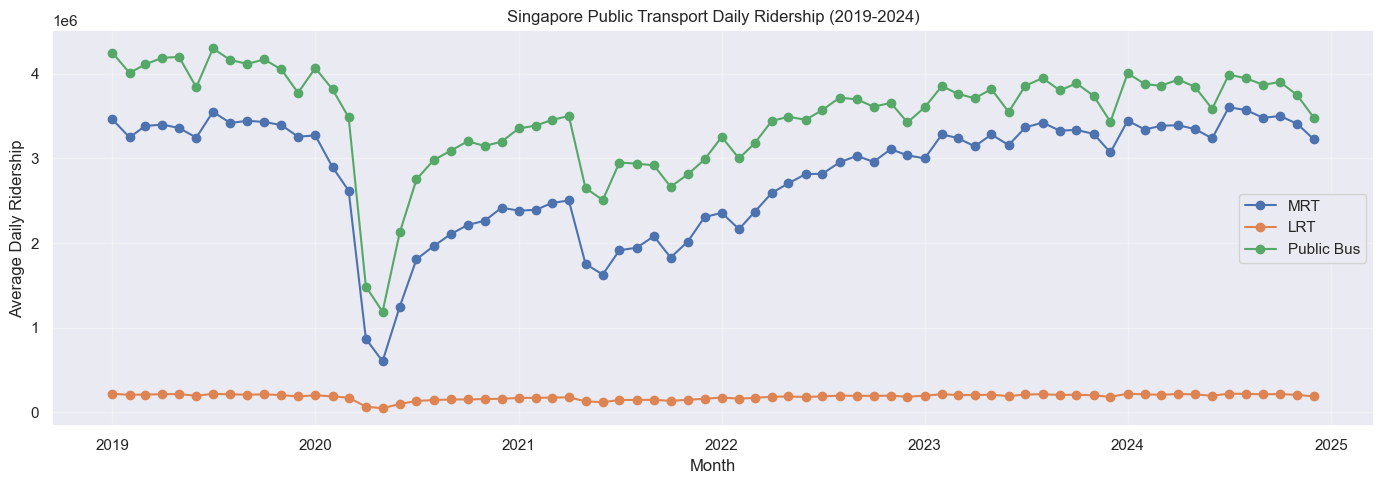

In [4]:
# ================================
# 4. Time Series Visualisation
# ================================

# This converts month to datetime
df['date'] = pd.to_datetime(df['month'], format='%b-%y')

# This sorts by date
df = df.sort_values('date')

# This plots the ridership trends for all three modes
plt.figure(figsize=(14, 5))
for mode in df['mode'].unique():
    mode_data = df[df['mode'] == mode]
    plt.plot(mode_data['date'], mode_data['ridership'], marker='o', label=mode)

plt.title("Singapore Public Transport Daily Ridership (2019-2024)")
plt.xlabel("Month")
plt.ylabel("Average Daily Ridership")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Seasonality Analysis

Breaking down average MRT ridership by calendar month to identify recurring seasonal patterns throughout the year.

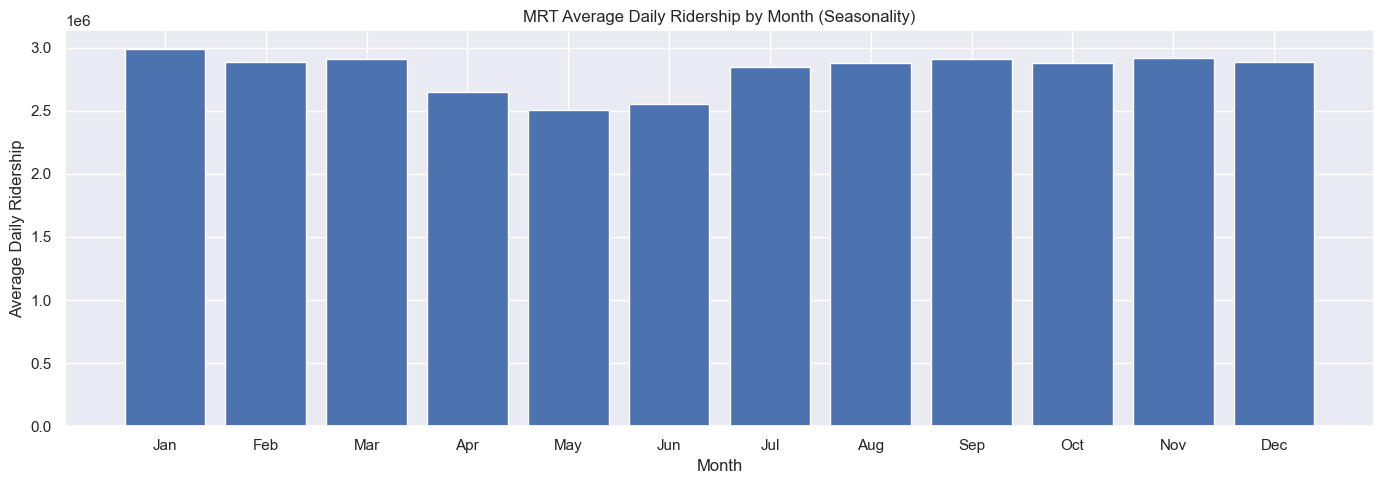

In [5]:
# ================================
# 5. Seasonality Analysis
# ================================

# This focuses on MRT only for seasonality analysis
mrt = df[df['mode'] == 'MRT'].copy()

# This extracts the month number for seasonality
mrt['month_num'] = mrt['date'].dt.month
mrt['year'] = mrt['date'].dt.year

# This averages ridership by calander month across all years
monthly_avg = mrt.groupby('month_num')['ridership'].mean()

# This is the plot
plt.figure(figsize=(14, 5))
plt.bar(monthly_avg.index, monthly_avg.values)
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title("MRT Average Daily Ridership by Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Daily Ridership")
plt.tight_layout()
plt.show()

## 6. Top Stations by Ridership

Comparing total ridership across MRT, LRT, and Public Bus over the full period.

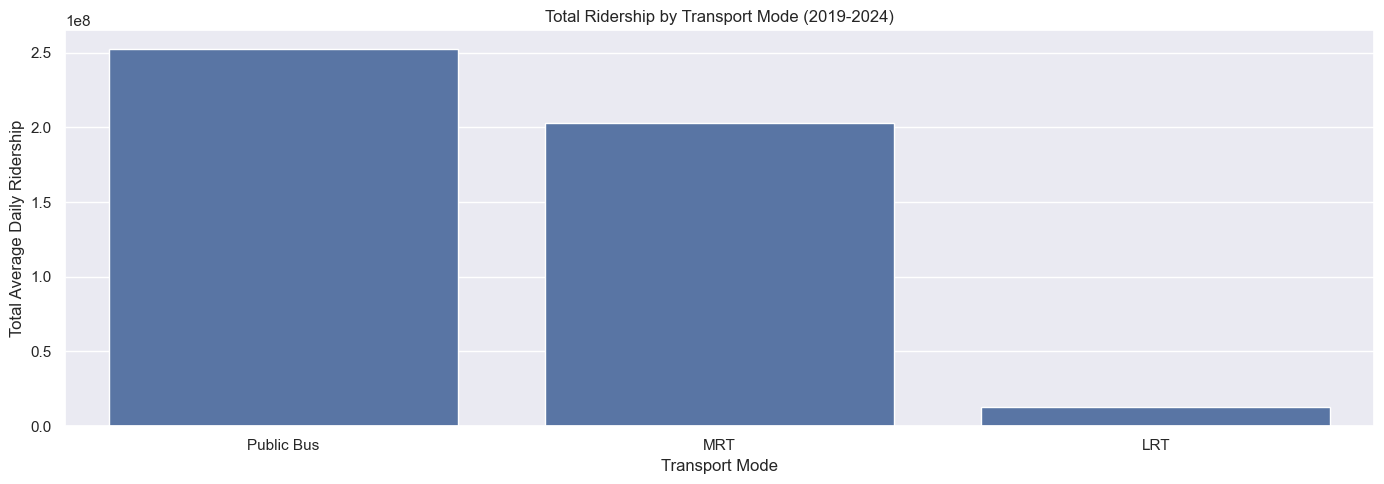

In [6]:
# ================================
# 6. Mode Comparison
# ================================

# This totals the ridership per mode across the entire period
mode_total = df.groupby('mode')['ridership'].sum().reset_index()
mode_total = mode_total.sort_values('ridership', ascending=False)

# This is the plot
plt.figure(figsize=(14, 5))
sns.barplot(data=mode_total, x='mode', y='ridership')
plt.title("Total Ridership by Transport Mode (2019-2024)")
plt.xlabel("Transport Mode")
plt.ylabel("Total Average Daily Ridership")
plt.tight_layout()
plt.show()

## 7. Anomaly Detection

Identifying unusual spikes or dips in ridership that may affect model performance and require special handling.

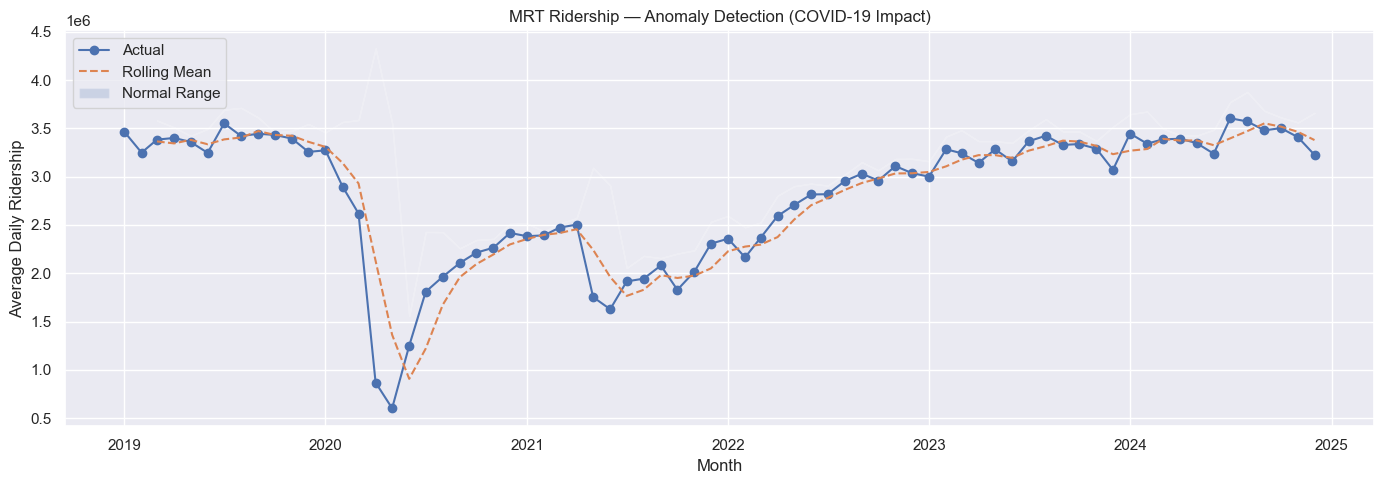

In [7]:
# ================================
# 7. Anomaly Detection
# ================================

# This focuses on MRT for anomaly detection
mrt = df[df['mode'] == 'MRT'].copy().sort_values('date')

# This calculates the rolling mean and standard deviation
mrt['rolling_mean'] = mrt['ridership'].rolling(window=3).mean()
mrt['rolling_std'] = mrt['ridership'].rolling(window=3).std()

# This defines the upper and lower bounds (2 std)
mrt['upper_bound'] = mrt['rolling_mean'] + (2 * mrt['rolling_std'])
mrt['lower_bound'] = mrt['rolling_mean'] + (2 * mrt['rolling_std'])

# This is the plot
plt.figure(figsize=(14, 5))
plt.plot(mrt['date'], mrt['ridership'], marker='o', label='Actual')
plt.plot(mrt['date'], mrt['rolling_mean'], linestyle='--', label='Rolling Mean')
plt.fill_between(mrt['date'], mrt['lower_bound'], mrt['upper_bound'], alpha=0.2, label='Normal Range')
plt.title("MRT Ridership — Anomaly Detection (COVID-19 Impact)")
plt.xlabel("Month")
plt.ylabel("Average Daily Ridership")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Data Export

Saving the cleaned and processed data to the 'data/processed/' folder, ready for modelling.

In [9]:
# ================================
# 8. Data Export
# ================================

# This filters MRT only for modelling
mrt_model = df[df['mode'] == 'MRT'][['date', 'ridership']].copy()
mrt_model = mrt_model.sort_values('date').reset_index(drop=True)

# This converts the date back to string for clean CSV export
mrt_model['date'] = mrt_model['date'].dt.strftime('%Y-%m')

# This saves the processed data
os.makedirs("data/processed", exist_ok=True)
processed_filepath = os.path.join("data", "processed", "mrt_ridership_processed.csv")
mrt_model.to_csv(processed_filepath, index=False)

print(f"Processed data saved to {processed_filepath}")
print(f"Shape: {mrt_model.shape}")
print(mrt_model.head())

Processed data saved to data\processed\mrt_ridership_processed.csv
Shape: (72, 2)
      date  ridership
0  2019-01    3462000
1  2019-02    3248000
2  2019-03    3383000
3  2019-04    3400000
4  2019-05    3359000
